In [ ]:
 import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
vocab_size = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

RNN

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 99ms/step - accuracy: 0.7212 - loss: 0.5310 - val_accuracy: 0.8372 - val_loss: 0.3879
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.8692 - loss: 0.3104 - val_accuracy: 0.8014 - val_loss: 0.4463
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9367 - loss: 0.1711 - val_accuracy: 0.8284 - val_loss: 0.4625
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.9769 - loss: 0.0719 - val_accuracy: 0.8214 - val_loss: 0.5443
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9906 - loss: 0.0320 - val_accuracy: 0.8298 - val_loss: 0.6289


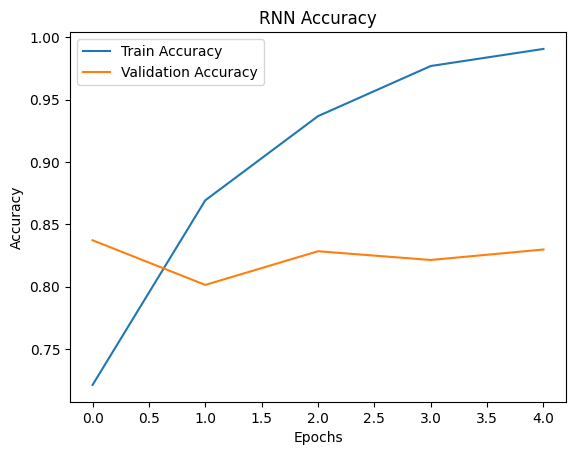

In [ ]:
model_rnn = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

plot_history(history_rnn, "RNN Accuracy")

LSTM

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 277ms/step - accuracy: 0.8029 - loss: 0.4235 - val_accuracy: 0.8614 - val_loss: 0.3348
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 283ms/step - accuracy: 0.8986 - loss: 0.2593 - val_accuracy: 0.8622 - val_loss: 0.3167
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 279ms/step - accuracy: 0.9308 - loss: 0.1846 - val_accuracy: 0.8536 - val_loss: 0.3479
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 262ms/step - accuracy: 0.9527 - loss: 0.1329 - val_accuracy: 0.8610 - val_loss: 0.3862
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 263ms/step - accuracy: 0.9567 - loss: 0.1173 - val_accuracy: 0.8556 - val_loss: 0.4637


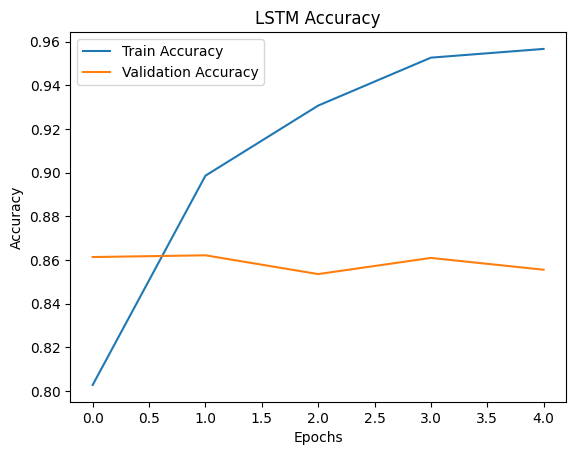

In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

plot_history(history_lstm, "LSTM Accuracy")

GRU

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 288ms/step - accuracy: 0.7747 - loss: 0.4544 - val_accuracy: 0.8576 - val_loss: 0.3423
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 300ms/step - accuracy: 0.8954 - loss: 0.2641 - val_accuracy: 0.8742 - val_loss: 0.3294
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 286ms/step - accuracy: 0.9313 - loss: 0.1783 - val_accuracy: 0.8696 - val_loss: 0.3847
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 297ms/step - accuracy: 0.9564 - loss: 0.1206 - val_accuracy: 0.8654 - val_loss: 0.3556
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 285ms/step - accuracy: 0.9762 - loss: 0.0717 - val_accuracy: 0.8702 - val_loss: 0.4591


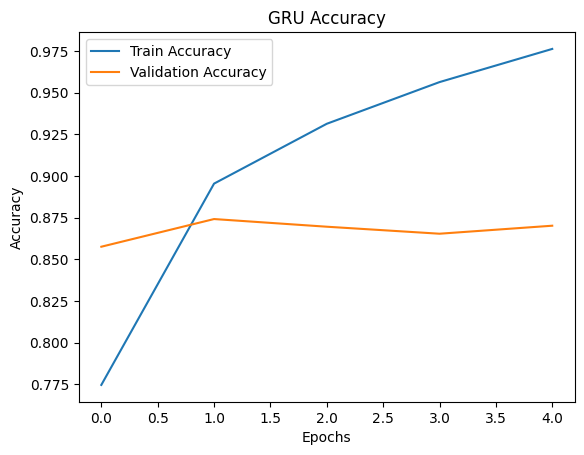

In [ ]:
model_gru = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

plot_history(history_gru, "GRU Accuracy")

Final Comparison

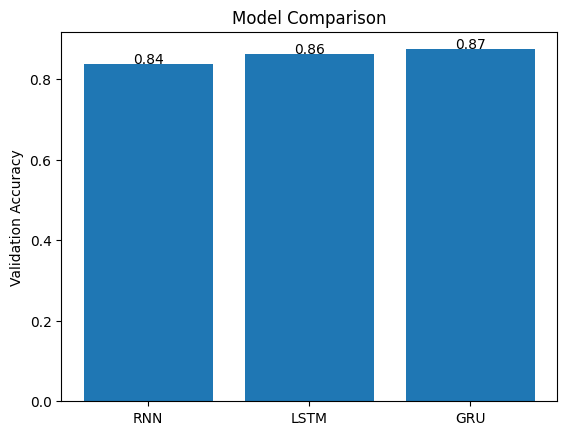

In [ ]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [
    max(history_rnn.history['val_accuracy']),
    max(history_lstm.history['val_accuracy']),
    max(history_gru.history['val_accuracy'])
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center')

plt.show()